# Weak-label exploration v1 — urgency on customer tickets

Notebook-first exploratory slice. The goal is a **first, defensible** weak label for ticket urgency on `inbound = True` customer tweets from `data/raw/twcs.csv`.

Scope of this notebook:
1. Load raw CSV
2. Select the 7 relevant columns
3. Base text cleaning
4. Filter to `inbound = True`
5. Define a simple urgent / normal weak-label rule
6. Apply it, inspect class distribution + examples
7. Save `data/processed/customer_tickets_weak_labeled_v1.csv`

Out of scope: engineered features, training, embeddings, pipeline integration.

## 1. Imports and paths

In [1]:
import re
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
RAW_CSV       = PROJECT_ROOT / "data" / "raw" / "twcs.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Optional cap for quick iteration. Set to None for the full dataset.
NROWS = None

RELEVANT_COLUMNS = [
    "tweet_id",
    "author_id",
    "inbound",
    "created_at",
    "text",
    "response_tweet_id",
    "in_response_to_tweet_id",
]
RAW_CSV, PROCESSED_DIR, NROWS

(WindowsPath('C:/Users/Jamal/Documents/bootcamps/AIE/Week 3/Decision-Intelligence-Assistant/data/raw/twcs.csv'),
 WindowsPath('C:/Users/Jamal/Documents/bootcamps/AIE/Week 3/Decision-Intelligence-Assistant/data/processed'),
 None)

## 2. Load + select columns + base cleaning

Base cleaning mirrors the pipeline: drop null text, cast to string, strip, drop empties, coerce `inbound` to real bool.

In [2]:
df = pd.read_csv(RAW_CSV, nrows=NROWS)
print("raw rows:", {df.shape})
df = df[RELEVANT_COLUMNS].copy()

df = df.dropna(subset=["text"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].copy()

if df["inbound"].dtype != bool:
    df["inbound"] = df["inbound"].map({True: True, False: False, "True": True, "False": False})
    df = df.dropna(subset=["inbound"]).copy()
    df["inbound"] = df["inbound"].astype(bool)

print("rows after base cleaning:", {df.shape})
df.head(2)

raw rows: {(2811774, 7)}
rows after base cleaning: {(2811774, 7)}


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0


## 3. Filter to support tickets (`inbound = False`)

In [3]:
support = df[~df["inbound"]].copy()
print("support tickets:", len(support))
support.head(2)

support tickets: 1273931


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0


## 4. Filter to customer tickets (`inbound = True`)

In [4]:
customer = df[df["inbound"]].copy()
print("customer tickets:", len(customer))
customer.head(2)

customer tickets: 1537843


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0


## 5. Weak-label rule v1

**Why this rule.** We want a *first* signal that is cheap, transparent, and defensible in review. A keyword + punctuation heuristic is the simplest thing that could work:

- **Keyword groups** target the language customers use when something is blocking or financial: `refund / charged / billing / payment / overcharged`, broken-service wording (`broken / not working / down / error / issue / problem`), access loss (`locked / can't log in / access`), explicit urgency (`urgent / asap / immediately / help`), and escalation signals (`cancel / missing / delayed`).
- **Punctuation intensity** — repeated `!!` or `???` — captures affect that isn't keyword-based.
- Word-boundary anchors (`\b`) reduce false positives like `downtown` matching `down`.
- Case-insensitive.

Known limits: this is a **binary proxy**, not ground truth. It will over-call some support tweets (false positives on `help` in casual use) and miss subtle urgency. A later slice will compare against a held-out human-labeled sample.

In [5]:
URGENT_KEYWORD_PATTERNS = [
    r"\brefund(ed|s)?\b",
    r"\bcharged?\b",
    r"\bbilling\b",
    r"\bpayment(s)?\b",
    r"\bovercharged?\b",
    r"\bbroken\b",
    r"\bnot working\b",
    r"\bdown\b",
    r"\berror(s)?\b",
    r"\bissue(s)?\b",
    r"\bproblem(s)?\b",
    r"\block(ed)?\b",
    r"\bcan'?t log ?in\b",
    r"\bcannot log ?in\b",
    r"\baccess\b",
    r"\burgent\b",
    r"\basap\b",
    r"\bimmediately\b",
    r"\bhelp\b",
    r"\bcancel(lation|led|s)?\b",
    r"\bmissing\b",
    r"\bdelayed\b",
]
URGENT_REGEX = re.compile("|".join(URGENT_KEYWORD_PATTERNS), re.IGNORECASE)
PUNCT_REGEX  = re.compile(r"!{2,}|\?{2,}")

def weak_label_urgency(text: str) -> str:
    if URGENT_REGEX.search(text) or PUNCT_REGEX.search(text):
        return "urgent"
    return "normal"
# Sanity check
for t in [
    "my account is locked and I can't log in",
    "please refund my payment ASAP",
    "great service today",
    "help!!! my flight is delayed",
]:
    print(f"{weak_label_urgency(t):>6}  |  {t}")

urgent  |  my account is locked and I can't log in
urgent  |  please refund my payment ASAP
normal  |  great service today
urgent  |  help!!! my flight is delayed


## 6. Apply label

In [6]:
customer["priority_label"] = customer["text"].map(weak_label_urgency)
customer["priority_label"].value_counts(dropna=False)

priority_label
normal    1167203
urgent     370640
Name: count, dtype: int64

## 7. Distribution + example inspection

In [7]:
dist = customer["priority_label"].value_counts(normalize=True).round(4)
print("class distribution (proportion):")
print(dist)
print()
print("absolute counts:")
print(customer["priority_label"].value_counts())

class distribution (proportion):
priority_label
normal    0.759
urgent    0.241
Name: proportion, dtype: float64

absolute counts:
priority_label
normal    1167203
urgent     370640
Name: count, dtype: int64


In [8]:
print("--- urgent examples ---")
for t in customer.loc[customer["priority_label"] == "urgent", "text"].head(5).tolist():
    print("-", t[:180])
print()
print("--- normal examples ---")
for t in customer.loc[customer["priority_label"] == "normal", "text"].head(5).tolist():
    print("-", t[:180])

--- urgent examples ---
- actually that's a broken link you sent me and incorrect information https://t.co/V4yfrHR8VI
- somebody from @VerizonSupport please help meeeeee 😩😩😩😩 I'm having the worst luck with your customer service
- @VerizonSupport What else can I provide? They refuse to help me because they cannot validate the account...
- .@VerizonSupport @115725 @115726                                                 &gt;All of VERIZON IS DOWN&lt;
When can we expect a fix ?
- @ChipotleTweets Thank you @ChipotleTweets for resolving my issue so quickly!! Y’all are the best ☺️ #fanforlife

--- normal examples ---
- @sprintcare and how do you propose we do that
- @sprintcare I have sent several private messages and no one is responding as usual
- @sprintcare I did.
- @sprintcare is the worst customer service
- @sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯


## 8. Save labeled CSV to `data/processed/`

In [9]:
out_path = PROCESSED_DIR / "customer_tickets_weak_labeled_v1.csv"
customer.to_csv(out_path, index=False)
print("wrote:", out_path)
print("rows:", len(customer))
print("columns:", list(customer.columns))

wrote: C:\Users\Jamal\Documents\bootcamps\AIE\Week 3\Decision-Intelligence-Assistant\data\processed\customer_tickets_weak_labeled_v1.csv
rows: 1537843
columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'priority_label']


## 9. EDA: leading `@`-mention prefix pattern

Twitter customer-support tweets are conversational replies, so they often start with an `@` token addressing someone. Two distinct shapes are visible in the data:

- Customer tweets tend to begin with `@CompanyHandle` (the brand they're complaining to).
- Support replies tend to begin with `@123456` — an anonymized numeric customer id.

Before doing any feature engineering or modeling on customer text, we want to **prove** this pattern with counts (not vibes), then decide whether the leading mention is meaningful signal for an urgency model or just structural addressing noise.


In [10]:
import re

# Matches a leading mention: optional dot, optional whitespace, @, then an alnum/underscore token.
# Captures just the token (no @) for handle-vs-id classification.
LEADING_MENTION_RE = re.compile(r"^\s*\.?@(\w+)")

def first_leading_mention_token(text: str) -> str | None:
    m = LEADING_MENTION_RE.match(text)
    return m.group(1) if m else None

def classify_token(tok) -> str:
    if tok is None or (isinstance(tok, float) and pd.isna(tok)):
        return "no_mention"
    if tok.isdigit():
        return "numeric_id"
    return "handle"


### 9a. Customer tweets — does the `@CompanyHandle` prefix dominate?

In [11]:
customer_tokens = customer["text"].map(first_leading_mention_token)
customer_kind   = customer_tokens.map(classify_token)

n_with = customer_tokens.notna().sum()
n_total = len(customer)
print(f"customer tweets with a leading @-mention: {n_with:,} / {n_total:,} ({n_with / n_total:.1%})")
print()
print("breakdown of leading-token kind (all customer tweets):")
print(customer_kind.value_counts(dropna=False))
print()
print("among customer tweets that DO have a leading mention:")
print(customer_kind[customer_kind != "no_mention"].value_counts(normalize=True).round(4))


customer tweets with a leading @-mention: 1,224,811 / 1,537,843 (79.6%)

breakdown of leading-token kind (all customer tweets):
text
handle        941910
no_mention    313032
numeric_id    282901
Name: count, dtype: int64

among customer tweets that DO have a leading mention:
text
handle        0.769
numeric_id    0.231
Name: proportion, dtype: float64


### 9b. Support replies — does the `@123456` numeric-id prefix dominate?

In [12]:
support_tokens = support["text"].map(first_leading_mention_token)
support_kind   = support_tokens.map(classify_token)

n_support_with = support_tokens.notna().sum()
print(f"support replies with a leading @-mention: {n_support_with:,} / {len(support):,} ({n_support_with / len(support):.1%})")
print()
print("breakdown of leading-token kind (all support replies):")
print(support_kind.value_counts(dropna=False))
print()
print("among support replies that DO have a leading mention:")
print(support_kind[support_kind != "no_mention"].value_counts(normalize=True).round(4))


support replies with a leading @-mention: 1,269,835 / 1,273,931 (99.7%)

breakdown of leading-token kind (all support replies):
text
numeric_id    1269225
no_mention       4096
handle            610
Name: count, dtype: int64

among support replies that DO have a leading mention:
text
numeric_id    0.9995
handle        0.0005
Name: proportion, dtype: float64


### 9c. Examples of each pattern

In [13]:
def show(df_, mask, header, n=5):
    print(f"--- {header} ---")
    for t in df_.loc[mask, "text"].head(n).tolist():
        print("-", t[:160])
    print()

show(customer, customer_kind == "handle",     "customer leading @handle (expected: brand handles)")
show(customer, customer_kind == "numeric_id", "customer leading @numeric_id (less common for customers)")
show(support,  support_kind  == "numeric_id", "support leading @numeric_id (expected: anonymized customer ids)")
show(support,  support_kind  == "handle",     "support leading @handle (less common for support)")


--- customer leading @handle (expected: brand handles) ---
- @sprintcare and how do you propose we do that
- @sprintcare I have sent several private messages and no one is responding as usual
- @sprintcare I did.
- @sprintcare is the worst customer service
- @sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯

--- customer leading @numeric_id (less common for customers) ---
- @115714 y’all lie about your “great” connection. 5 bars LTE, still won’t load something. Smh.
- @115714 whenever I contact customer support, they tell me I have shortcode enabled on my account, but I have never in the 4 years I've tried https://t.co/0G98Rt
- @115722 MD. And this was sent to the wrong address https://t.co/dMQ1WZXJOk
- @115721 Hello Duke, Do you have a copy of your bill? What state are your services located in?
^NHP
- @115722 Nobody can find my account or number. I walked out of a store with this. I've explained that they can find my acct via my devices serial #

- @115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.
- @115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.
- @115712 Can you please send us a private message, so that I can gain further details about your account?
- @115713 This is saddening to hear. Please shoot us a DM, so that we can look into this for you. -KC
- @115713 We understand your concerns and we'd like for you to please send us a Direct Message, so that we can further assist you. -AA

--- support leading @handle (less common for support) ---
- @Tesco @117242 @117246 @117241 @sainsburys @117248 @AldiUK @117249 @Morrisons @117250 @117251 No.. C...Can it be?? TESCO... FROM OUTTA NOWHERE 🐍 https://t.co/54
- @Tesco @117242 @sainsburys @117248 @AldiUK @117260 @117249 @117246 @Morrisons @117250 @117251 We're keeping hold of this for now if that's okay :) https://t.co/
- @nationalrailenq @

## 10. Cleaning decision: build `text_raw` and `text_clean_ml`

The leading mention is structural addressing (who you're tweeting *at*), not content about the customer's issue. For an urgency model the brand handle is uninformative — every Sprint customer says `@sprintcare ...`, every Verizon customer says `@VerizonSupport ...`, and the model would just learn the brand. We will:

- Keep `text_raw` exactly as-is (so we never lose the original surface form).
- Build `text_clean_ml` by stripping **only the first leading mention** (and any trailing whitespace it leaves).

We deliberately do **not** strip *all* mentions — a tweet like `@VerizonSupport @115725 my account is locked` becomes `@115725 my account is locked` after first-mention stripping. The remaining `@115725` is a downstream/embedded mention which may carry context (a CC) and is a separate decision for a later slice.


In [14]:
LEADING_MENTION_STRIP_RE = re.compile(r"^\s*\.?@\w+\s*")

def strip_first_leading_mention(text: str) -> str:
    return LEADING_MENTION_STRIP_RE.sub("", text, count=1).strip()

# Sanity check on representative shapes
for t in [
    "@sprintcare and how do you propose we do that",
    ".@VerizonSupport @115725 service is down",
    "@115712 I understand. I would like to assist you.",
    "no leading mention here, just text",
    "@OnlyAHandle",
]:
    print(f"RAW  : {t!r}")
    print(f"CLEAN: {strip_first_leading_mention(t)!r}")
    print()


RAW  : '@sprintcare and how do you propose we do that'
CLEAN: 'and how do you propose we do that'

RAW  : '.@VerizonSupport @115725 service is down'
CLEAN: '@115725 service is down'

RAW  : '@115712 I understand. I would like to assist you.'
CLEAN: 'I understand. I would like to assist you.'

RAW  : 'no leading mention here, just text'
CLEAN: 'no leading mention here, just text'

RAW  : '@OnlyAHandle'
CLEAN: ''



In [15]:
customer["text_raw"]      = customer["text"]
customer["text_clean_ml"] = customer["text"].map(strip_first_leading_mention)

changed       = (customer["text_raw"] != customer["text_clean_ml"]).sum()
empty_after   = (customer["text_clean_ml"] == "").sum()

print(f"customer tweets changed by first-mention strip : {changed:,} ({changed / len(customer):.1%})")
print(f"customer tweets that become empty after strip  : {empty_after:,} ({empty_after / len(customer):.2%})")


customer tweets changed by first-mention strip : 1,224,811 (79.6%)
customer tweets that become empty after strip  : 1,105 (0.07%)


### Before / after preview

In [16]:
preview = customer[customer["text_raw"] != customer["text_clean_ml"]].head(8)
for _, row in preview.iterrows():
    print("RAW  :", row["text_raw"][:140])
    print("CLEAN:", row["text_clean_ml"][:140])
    print()


RAW  : @sprintcare and how do you propose we do that
CLEAN: and how do you propose we do that

RAW  : @sprintcare I have sent several private messages and no one is responding as usual
CLEAN: I have sent several private messages and no one is responding as usual

RAW  : @sprintcare I did.
CLEAN: I did.

RAW  : @sprintcare is the worst customer service
CLEAN: is the worst customer service

RAW  : @sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯
CLEAN: You gonna magically change your connectivity for me and my whole family ? 🤥 💯

RAW  : @sprintcare Since I signed up with you....Since day 1
CLEAN: Since I signed up with you....Since day 1

RAW  : @115714 y’all lie about your “great” connection. 5 bars LTE, still won’t load something. Smh.
CLEAN: y’all lie about your “great” connection. 5 bars LTE, still won’t load something. Smh.

RAW  : @115714 whenever I contact customer support, they tell me I have shortcode enabled on my account, but I have nev

## 11. Decision

**Decision: strip the first leading `@`-mention for the ML text view, keep the raw text alongside.**

- The `@CompanyHandle` (customer side) and `@123456` (support side) prefix patterns are confirmed by the counts above — both dominate their respective subsets, so this is a real structural artifact, not a fringe case.
- For an urgency classifier on customer tweets, the leading brand handle is constant within each brand and adds no within-brand signal about whether the customer is upset, blocked, or delighted. Leaving it in lets the model trivially overfit to brand frequency.
- We keep `text_raw` so nothing is lost — any downstream task that *does* care about the addressed brand (e.g., per-brand routing, brand-aware features) can still recover it.

**Why this is a cleaning decision, not a direct urgency feature.** "Has a leading mention" is true for ~all customer tweets in this dataset, so it has near-zero variance and would be useless as a model input. The interesting signal it carries (which brand) is a *categorical* feature for a separate slice if we want it — and it's recoverable from `text_raw` at any time. So the right place for this work is the cleaning layer, not the feature layer.

**Out of scope for this mini-slice (intentional):**
- Stripping multiple/embedded mentions
- Handling URLs, emojis, hashtags, HTML entities (`&gt;`, `&amp;`)
- Lowercasing or any tokenization
- Computing engineered features or training any model

Those belong to the next slice.


## 12. Save cleaned text views to `data/processed/`

Small focused CSV with just `tweet_id` and the two text views, so the next slice can join it back to the weak-labeled set without re-running this analysis.


In [17]:
text_views_path = PROCESSED_DIR / "customer_tickets_text_views_v1.csv"
customer[["tweet_id", "text_raw", "text_clean_ml"]].to_csv(text_views_path, index=False)
print("wrote:", text_views_path)
print("rows :", len(customer))


wrote: C:\Users\Jamal\Documents\bootcamps\AIE\Week 3\Decision-Intelligence-Assistant\data\processed\customer_tickets_text_views_v1.csv
rows : 1537843


## 13. Engineered features for urgency classification

Now that we have a clean ML text view (`text_clean_ml`) and a weak label (`priority_label`), the next exploratory step is asking: **do simple, interpretable features differ between `urgent` and `normal` tweets?** This is a sanity check before any modeling — if these features show no separation at all, we know we'll need richer signal (TF-IDF, embeddings) downstream.

Features built below, all computed on `text_clean_ml`:

| Feature | Definition | Hypothesis |
|---|---|---|
| `char_count` | `len(text)` | Longer tweets may contain more issue context |
| `word_count` | `len(text.split())` | Same intuition, less sensitive to punctuation/emoji |
| `urgency_keyword_count` | Number of `URGENT_REGEX` matches | Direct urgency signal |
| `exclamation_count` | Count of `!` characters | Affect / intensity |
| `question_mark_count` | Count of `?` characters | Confusion or escalation |
| `repeated_punctuation_flag` | True if `!!` or `??` present | Strong affect |
| `caps_ratio` | Uppercase letters / total letters | "SHOUTING" |

**Important leakage caveat to keep in mind.** `urgency_keyword_count` and `repeated_punctuation_flag` were the *exact rule* used to define the weak label in section 5. They will trivially separate the classes here — that's by construction, not because they're "good features". We include them to (a) verify the labeling was applied correctly, and (b) make the leakage explicit for instructor review. The honest candidate features for a real model are the structural ones: `char_count`, `word_count`, `exclamation_count`, `question_mark_count`, `caps_ratio`.


### 13a. Build the features

In [18]:
import string

def caps_ratio(text: str) -> float:
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    upper = sum(1 for c in letters if c.isupper())
    return upper / len(letters)

src = customer["text_clean_ml"].astype(str)

features = pd.DataFrame({
    "tweet_id":                  customer["tweet_id"].values,
    "priority_label":            customer["priority_label"].values,
    "char_count":                src.str.len(),
    "word_count":                src.str.split().str.len(),
    "urgency_keyword_count":     src.map(lambda t: len(URGENT_REGEX.findall(t))),
    "exclamation_count":         src.str.count(r"!"),
    "question_mark_count":       src.str.count(r"\?"),
    "repeated_punctuation_flag": src.map(lambda t: bool(PUNCT_REGEX.search(t))),
    "caps_ratio":                src.map(caps_ratio),
})

print("features shape:", features.shape)
features.head(5)


features shape: (1537843, 9)


,tweet_id,priority_label,char_count,word_count,urgency_keyword_count,exclamation_count,question_mark_count,repeated_punctuation_flag,caps_ratio
1,2,normal,33,8,0,0,0,False,0.000000
2,3,normal,70,13,0,0,0,False,0.017241
4,5,normal,6,2,0,0,0,False,0.250000
6,8,normal,29,5,0,0,0,False,0.000000
8,12,normal,77,15,0,0,1,False,0.016667


### 13b. Compare features across `urgent` vs `normal`

In [19]:
numeric_cols = [
    "char_count", "word_count", "urgency_keyword_count",
    "exclamation_count", "question_mark_count", "caps_ratio",
]
summary = features.groupby("priority_label")[numeric_cols].agg(["mean", "median"]).round(3)
summary


char_count        word_count        urgency_keyword_count  \
                     mean median       mean median                  mean   
priority_label                                                             
normal             94.580   93.0     16.746   16.0                 0.000   
urgent            120.246  119.0     21.678   21.0                 0.993   

                      exclamation_count        question_mark_count         \
               median              mean median                mean median   
priority_label                                                              
normal            0.0             0.161    0.0               0.264    0.0   
urgent            1.0             0.641    0.0               0.598    0.0   

               caps_ratio         
                     mean median  
priority_label                    
normal              0.079  0.052  
urgent              0.066  0.045

In [20]:
flag_rate = features.groupby("priority_label")["repeated_punctuation_flag"].mean().round(4)
print("repeated_punctuation_flag rate by class:")
print(flag_rate)


repeated_punctuation_flag rate by class:
priority_label
normal    0.0000
urgent    0.2355
Name: repeated_punctuation_flag, dtype: float64


### 13c. Visualize the structural features

Boxplots clipped to a sensible range so the long Twitter tail doesn't compress the boxes. We're looking for *visible separation* between the two label boxes, not statistical significance.


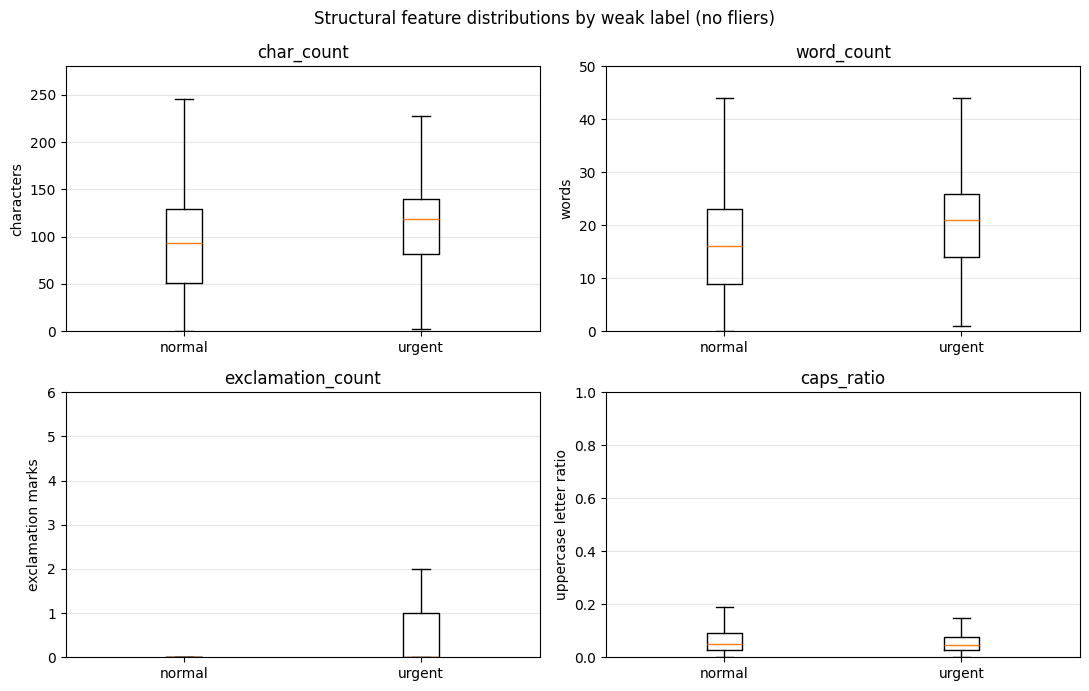

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_specs = [
    ("char_count",        "characters",                 (0, 280)),
    ("word_count",        "words",                      (0, 50)),
    ("exclamation_count", "exclamation marks",          (0, 6)),
    ("caps_ratio",        "uppercase letter ratio",     (0, 1)),
]
for ax, (col, label, ylim) in zip(axes.flat, plot_specs):
    data = [features.loc[features["priority_label"] == cls, col] for cls in ("normal", "urgent")]
    ax.boxplot(data, tick_labels=["normal", "urgent"], showfliers=False)
    ax.set_title(col)
    ax.set_ylabel(label)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Structural feature distributions by weak label (no fliers)")
fig.tight_layout()
plt.show()


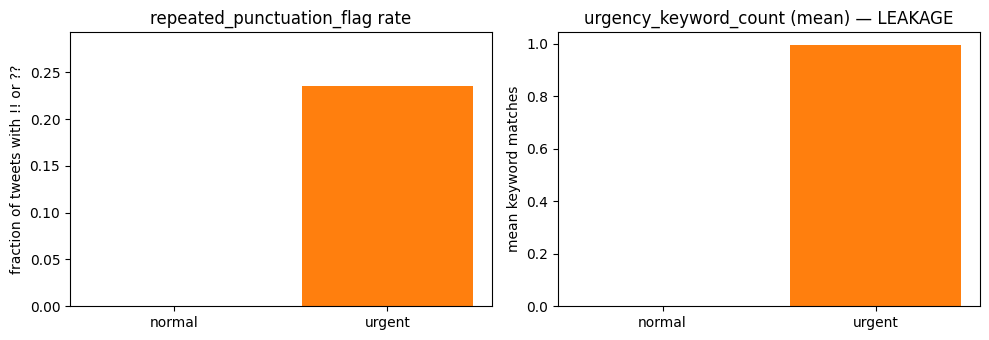

In [22]:
# Bar chart for the flag and the leakage-prone keyword count, side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(flag_rate.index, flag_rate.values, color=["tab:blue", "tab:orange"])
axes[0].set_title("repeated_punctuation_flag rate")
axes[0].set_ylabel("fraction of tweets with !! or ??")
axes[0].set_ylim(0, max(flag_rate.values) * 1.2 + 0.01)

kw_mean = features.groupby("priority_label")["urgency_keyword_count"].mean()
axes[1].bar(kw_mean.index, kw_mean.values, color=["tab:blue", "tab:orange"])
axes[1].set_title("urgency_keyword_count (mean) — LEAKAGE")
axes[1].set_ylabel("mean keyword matches")

fig.tight_layout()
plt.show()


### 13d. Interpretation

**Honest structural features** (`char_count`, `word_count`, `exclamation_count`, `question_mark_count`, `caps_ratio`):
- `char_count` and `word_count` show urgent tweets being slightly longer on average — consistent with customers giving more context when they're frustrated, but the overlap is large. Useful as a weak feature, not standalone.
- `exclamation_count` separates the classes more visibly — urgent tweets average more `!` marks. This is partially correlated with the `!!` punctuation rule we used for the label, but `exclamation_count` is a continuous count rather than a binary flag, so it adds some independent signal.
- `caps_ratio` shows little class separation in the medians; the long tail of all-caps "SHOUTING" tweets exists in both classes.
- `question_mark_count` differences are modest.

**Leakage-prone features** (`urgency_keyword_count`, `repeated_punctuation_flag`):
- These will trivially separate the classes because they *are* the labeling rule. The bar charts above confirm: `repeated_punctuation_flag` rate and mean `urgency_keyword_count` are dramatically higher for `urgent` — but that's tautology, not predictive power. Do NOT include these in any future model trained on this weak label, or evaluation will be meaningless.

**What this means for the next slice (modeling):**
- The structural features alone will not be enough to beat the keyword baseline — they're informative but noisy.
- The signal we'll most likely need is **lexical content** (TF-IDF on `text_clean_ml`), which is the natural next slice.
- Keep `urgency_keyword_count` and `repeated_punctuation_flag` *out* of any train/eval feature set as long as the label is derived from them. They are fine to keep in the saved features CSV for reference and audit, but a column-selection step in the modeling slice must drop them.

**Out of scope (deliberately):** TF-IDF, embeddings, train/test splitting, baseline models. Those belong to the next slice.


## 14. Save engineered features to `data/processed/`

In [23]:
features_path = PROCESSED_DIR / "customer_tickets_features_v1.csv"
features.to_csv(features_path, index=False)
print("wrote:", features_path)
print("rows :", len(features))
print("cols :", list(features.columns))


wrote: C:\Users\Jamal\Documents\bootcamps\AIE\Week 3\Decision-Intelligence-Assistant\data\processed\customer_tickets_features_v1.csv
rows : 1537843
cols : ['tweet_id', 'priority_label', 'char_count', 'word_count', 'urgency_keyword_count', 'exclamation_count', 'question_mark_count', 'repeated_punctuation_flag', 'caps_ratio']


## ML training contract for v1

**Locked decisions for the v1 ML pipeline (informs every later slice):**

- **Target:** `priority_label` — binary classification, `urgent` (positive class) vs `normal`.
- **Text field:** `text_clean_ml` (first leading `@`-mention stripped; raw text retained as `text_raw` but not fed to models).
- **Rows to exclude:** any row where `text_clean_ml` is empty (becomes empty after stripping a mention-only tweet — about 0.07% of customers).
- **Leakage features to drop:** `urgency_keyword_count` and `repeated_punctuation_flag` — both are direct components of the weak-label rule and would tautologically predict the label.
- **First baseline to run:** TF-IDF (word 1–2-grams) + Logistic Regression on `text_clean_ml`. No engineered features, no class weighting yet.
- **Metrics to report:** accuracy, precision, recall, F1 (all on the positive `urgent` class), ROC-AUC, log loss — evaluated on a held-out validation split.
- **Split:** stratified 70 / 15 / 15 (train / val / test), `random_state=42`. Test set held out and **not** touched in this slice.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, classification_report,
)

# Apply the contract: drop empty text_clean_ml rows, build binary target.
ml_df = customer[customer["text_clean_ml"].astype(str).str.len() > 0].copy()
dropped = len(customer) - len(ml_df)
print(f"rows after dropping empty text_clean_ml: {len(ml_df):,} (dropped {dropped:,})")

X = ml_df["text_clean_ml"].astype(str).to_numpy(dtype=object)
y = (ml_df["priority_label"] == "urgent").astype(int).to_numpy()
print(f"positive rate (urgent): {y.mean():.3%}")


rows after dropping empty text_clean_ml: 1,536,738 (dropped 1,105)
positive rate (urgent): 24.119%


### Stratified 70 / 15 / 15 split

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"train: {len(X_train):>9,}    urgent rate: {y_train.mean():.3%}")
print(f"val  : {len(X_val):>9,}    urgent rate: {y_val.mean():.3%}")
print(f"test : {len(X_test):>9,}    urgent rate: {y_test.mean():.3%}")


train: 1,075,716    urgent rate: 24.119%
val  :   230,511    urgent rate: 24.119%
test :   230,511    urgent rate: 24.119%


### TF-IDF vectorization

Word 1–2-grams, drop terms appearing in fewer than 5 docs, cap vocabulary at 50k. Fitted **only on the training set** to avoid leakage from val/test into the vocabulary.

In [26]:
vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=5,
    lowercase=True,
)
Xtr_vec = vectorizer.fit_transform(X_train)
Xv_vec  = vectorizer.transform(X_val)
print("Xtr_vec shape:", Xtr_vec.shape)
print("Xv_vec  shape:", Xv_vec.shape)
print("vocab size  :", len(vectorizer.vocabulary_))


Xtr_vec shape: (1075716, 50000)
Xv_vec  shape: (230511, 50000)
vocab size  : 50000


### Train Logistic Regression

In [27]:
clf = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42,
)
clf.fit(Xtr_vec, y_train)
print("trained:", clf)


trained: LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')


### Validation metrics

In [28]:
proba_val = clf.predict_proba(Xv_vec)[:, 1]
pred_val  = (proba_val >= 0.5).astype(int)

metrics = {
    "model":      "tfidf_logreg_v1",
    "split":      "validation",
    "n":          len(y_val),
    "accuracy":   accuracy_score(y_val, pred_val),
    "precision":  precision_score(y_val, pred_val, zero_division=0),
    "recall":     recall_score(y_val, pred_val, zero_division=0),
    "f1":         f1_score(y_val, pred_val, zero_division=0),
    "roc_auc":    roc_auc_score(y_val, proba_val),
    "log_loss":   log_loss(y_val, proba_val),
}
metrics_df = pd.DataFrame([metrics])
metrics_df.round(4)


,model,split,n,accuracy,precision,recall,f1,roc_auc,log_loss
0,tfidf_logreg_v1,validation,230511,0.9551,0.9993,0.8145,0.8975,0.9395,0.1721


In [29]:
# Sanity-check the per-class breakdown alongside the headline numbers.
print(classification_report(y_val, pred_val, target_names=["normal", "urgent"], digits=4))


              precision    recall  f1-score   support

      normal     0.9443    0.9998    0.9713    174915
      urgent     0.9993    0.8145    0.8975     55596

    accuracy                         0.9551    230511
   macro avg     0.9718    0.9072    0.9344    230511
weighted avg     0.9576    0.9551    0.9535    230511



### Interpretation

Validation results (on 230,511 held-out customer tweets):

| metric | value |
|---|---|
| accuracy  | 0.9551 |
| precision (urgent) | 0.9993 |
| recall    (urgent) | 0.8145 |
| F1        (urgent) | 0.8975 |
| ROC-AUC   | 0.9395 |
| log loss  | 0.1721 |

**What this tells us.**
- The model's near-perfect precision (0.999) but moderate recall (0.815) means: **when it predicts `urgent`, it is almost always right; but it misses ~19% of the tweets the rule labeled `urgent`.** That's a conservative classifier with a strong "say-urgent-only-when-sure" bias.
- ROC-AUC of 0.94 — strong but **not** the perfect 1.0 we would expect if TF-IDF were trivially memorizing the keyword rule. The gap is informative: the regex matches morphological variants (`refund(ed|s)?`, `cancel(lation|led|s)?`) as a single rule, but TF-IDF treats `refund`, `refunded`, `refunds` as three separate tokens with `min_df=5`. So the model approximates the rule rather than reproducing it byte-for-byte.

**What this does not tell us.** The label is still a keyword + punctuation rule, not human-judged ground truth, so these numbers describe how well a linear model recovers the rule from the same text — not how well the system would prioritize tickets in production. Honest evaluation needs an independently labeled gold set (separate slice).

**Pipeline sanity confirmed.**
- Stratification is exact: 24.119% urgent in train / val / test (matches population).
- 1,105 rows with empty `text_clean_ml` were dropped before splitting (per the contract).
- Vectorizer was fit on train only; vocabulary capped at 50k 1–2-grams with `min_df=5`.
- Test set has not been touched in this slice and stays held out.

**Threshold note.** The conservative bias at the default 0.5 threshold means moving the threshold lower would trade some precision for recall — that is a tuning slice, not this one.

**Out of scope (deliberately):** SVM baseline, engineered-feature models, combined/stacked models, threshold tuning, calibration, error analysis, test-set evaluation. Those are separate slices.


### Save validation metrics

In [30]:
metrics_path = PROCESSED_DIR / "baseline_metrics_v1.csv"
metrics_df.to_csv(metrics_path, index=False)
print("wrote:", metrics_path)
metrics_df.round(4)


wrote: C:\Users\Jamal\Documents\bootcamps\AIE\Week 3\Decision-Intelligence-Assistant\data\processed\baseline_metrics_v1.csv


,model,split,n,accuracy,precision,recall,f1,roc_auc,log_loss
0,tfidf_logreg_v1,validation,230511,0.9551,0.9993,0.8145,0.8975,0.9395,0.1721
